# Stage 3: Evaluation — Base vs SFT vs DPO on Held-Out Test Set

**Environment:** Kaggle GPU (P100/T4)  
**Estimated time:** ~45–60 minutes  
**Input:** Test set + SFT adapter + DPO adapter  
**Output:** `eval_results.json`, `metrics.csv`, charts

This notebook:
1. Generates responses from **Base Mistral 7B**, **SFT-tuned**, and **DPO-tuned** models
   on the held-out test set
2. Computes **ROUGE-L** scores against reference (chosen) responses
3. Analyzes **word count** distributions and length alignment
4. Produces **visualizations** (bar charts, histograms, scatter plots)
5. Shows **side-by-side** qualitative comparisons
6. Exports all metrics to CSV

## 1. Install Dependencies

In [1]:
!pip install -q transformers>=4.36.0 peft>=0.7.0 bitsandbytes>=0.41.0 accelerate>=0.25.0 datasets>=2.16.0

## 2. Verify Data Paths
Run this first to confirm exact paths on Kaggle.

In [2]:
import os
print("=== All files in /kaggle/input/ ===")
for root, dirs, files in os.walk('/kaggle/input/'):
    for f in files:
        print(os.path.join(root, f))

=== All files in /kaggle/input/ ===
/kaggle/input/datasets/aadityae/dpo-adapter/adapter_model.safetensors
/kaggle/input/datasets/aadityae/dpo-adapter/adapter_config.json
/kaggle/input/datasets/aadityae/dpo-adapter/README.md
/kaggle/input/datasets/aadityae/dpo-adapter/tokenizer.json
/kaggle/input/datasets/aadityae/dpo-adapter/tokenizer_config.json
/kaggle/input/datasets/aadityae/dpo-adapter/chat_template.jinja
/kaggle/input/datasets/aadityae/sft-adapter/adapter_model.safetensors
/kaggle/input/datasets/aadityae/sft-adapter/adapter_config.json
/kaggle/input/datasets/aadityae/sft-adapter/README.md
/kaggle/input/datasets/aadityae/sft-adapter/tokenizer.json
/kaggle/input/datasets/aadityae/sft-adapter/tokenizer_config.json
/kaggle/input/datasets/aadityae/sft-adapter/chat_template.jinja
/kaggle/input/datasets/aadityae/hr-preference-data/train.json
/kaggle/input/datasets/aadityae/hr-preference-data/test.json


## 3. Imports & Configuration
**IMPORTANT:** Update `SFT_ADAPTER_DIR`, `DPO_ADAPTER_DIR`, and `TEST_FILE` below if the paths from cell 2 differ.

In [4]:
import os
import json
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

# Disable W&B
os.environ["WANDB_DISABLED"] = "true"

# ── Paths ──
BASE_MODEL = "mistralai/Mistral-7B-Instruct-v0.2"
SFT_ADAPTER_DIR = "/kaggle/input/datasets/aadityae/sft-adapter"
DPO_ADAPTER_DIR = "/kaggle/input/datasets/aadityae/dpo-adapter"
TEST_FILE = "/kaggle/input/datasets/aadityae/hr-preference-data/test.json"
OUTPUT_FILE = "/kaggle/working/eval_results.json"

# ── Quantization ──
LOAD_IN_4BIT = True
BNB_4BIT_QUANT_TYPE = "nf4"
BNB_4BIT_COMPUTE_DTYPE = torch.float16  # float16, NOT bfloat16
BNB_4BIT_USE_DOUBLE_QUANT = True

# ── Generation ──
MAX_NEW_TOKENS = 300
TEMPERATURE = 0.7
DO_SAMPLE = True

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla P100-PCIE-16GB
Memory: 17.1 GB


## 4. Load Test Set

In [5]:
with open(TEST_FILE, "r", encoding="utf-8") as f:
    first_char = f.read(1)
    f.seek(0)
    if first_char == "[":
        # JSON array format
        test_data = json.load(f)
    else:
        # JSONL format (one JSON object per line) — Kaggle dataset uses this
        test_data = [json.loads(line) for line in f if line.strip()]

prompts = [item["prompt"] for item in test_data]
chosen_refs = [item["chosen"] for item in test_data]

print(f"Loaded {len(test_data)} test examples")
print(f"Sample prompt: {prompts[0][:100]}...")

Loaded 198 test examples
Sample prompt: How does the annual performance review process work?...


## 5. Load Base Model (4-bit Quantized)

In [6]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=LOAD_IN_4BIT,
    bnb_4bit_quant_type=BNB_4BIT_QUANT_TYPE,
    bnb_4bit_compute_dtype=BNB_4BIT_COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=BNB_4BIT_USE_DOUBLE_QUANT,
)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Base model loaded: {BASE_MODEL}")
print(f"Memory footprint: {base_model.get_memory_footprint() / 1e9:.2f} GB")

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Base model loaded: mistralai/Mistral-7B-Instruct-v0.2
Memory footprint: 4.01 GB


## 6. Generate Base Model Responses

In [7]:
def generate_responses(model, tokenizer, prompts, label="model"):
    """Generate a response for each prompt using [INST] format."""
    responses = []
    total = len(prompts)
    for i, prompt in enumerate(prompts):
        formatted = f"[INST] {prompt} [/INST]"
        inputs = tokenizer(formatted, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=TEMPERATURE,
                do_sample=DO_SAMPLE,
            )

        # Decode only the generated tokens (skip the input)
        generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
        response = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
        responses.append(response)

        if (i + 1) % 10 == 0 or (i + 1) == total:
            print(f"  [{label}] {i + 1}/{total} done")

    return responses

In [8]:
print("Generating base model responses...")
base_responses = generate_responses(base_model, tokenizer, prompts, label="base")
print(f"\nDone! Generated {len(base_responses)} base responses.")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Generating base model responses...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  [base] 10/198 done


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

  [base] 180/198 done


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  [base] 190/198 done


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  [base] 198/198 done

Done! Generated 198 base responses.


In [9]:
# Sanity check — print a sample base response
print("=" * 60)
print("SAMPLE BASE RESPONSE")
print("=" * 60)
print(f"Prompt:   {prompts[0]}")
print(f"\nResponse: {base_responses[0][:500]}")
print("=" * 60)

SAMPLE BASE RESPONSE
Prompt:   How does the annual performance review process work?

Response: The annual performance review process is a formal evaluation of an employee's job performance during a given year. The process typically involves the following steps:

1. Setting Performance Goals: At the beginning of the performance cycle, usually at the start of the fiscal year, an employee and their supervisor or manager work together to establish performance goals. These goals should be specific, measurable, achievable, relevant, and time-bound (SMART).

2. Regular Check-ins: Throughout the 


## 7. Load SFT Adapter & Generate SFT Responses

In [10]:
# Load SFT adapter on top of base model
sft_model = PeftModel.from_pretrained(base_model, SFT_ADAPTER_DIR, is_trainable=False)

print(f"SFT adapter loaded from: {SFT_ADAPTER_DIR}")
print(f"Memory footprint: {sft_model.get_memory_footprint() / 1e9:.2f} GB")

SFT adapter loaded from: /kaggle/input/datasets/aadityae/sft-adapter
Memory footprint: 4.07 GB


In [11]:
print("Generating SFT model responses...")
sft_responses = generate_responses(sft_model, tokenizer, prompts, label="sft")
print(f"\nDone! Generated {len(sft_responses)} SFT responses.")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Generating SFT model responses...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  [sft] 10/198 done


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

  [sft] 180/198 done


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  [sft] 190/198 done


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  [sft] 198/198 done

Done! Generated 198 SFT responses.


In [12]:
# Sanity check — print a sample SFT response
print("=" * 60)
print("SAMPLE SFT RESPONSE")
print("=" * 60)
print(f"Prompt:   {prompts[0]}")
print(f"\nResponse: {sft_responses[0][:500]}")
print("=" * 60)

SAMPLE SFT RESPONSE
Prompt:   How does the annual performance review process work?

Response: The annual performance review process typically involves the following steps:

- **Evaluation Criteria**: Employee performance is assessed based on:
  - Ownership and adherence to timelines
  - Quality of work
  - Initiative, dedication, and teamwork
  - Upskilling efforts and work knowledge
  - Communication skills, especially on Teams
  - Personality and punctuality
  - Past performance reviews and improvements
  - Acceptance of responsibility and constructive feedback

- **Review Process**: 



## 8. Load DPO Model & Generate DPO Responses

The DPO adapter was trained on top of the merged SFT model. So we must:
1. Merge SFT adapter into the base model weights
2. Load the DPO adapter on top of the merged model

We first free the SFT PEFT model to reclaim VRAM.

In [13]:
# Free the SFT PEFT wrapper (but keep underlying base_model)
del sft_model
torch.cuda.empty_cache()

# Step 1: Reload SFT adapter and merge into base weights
print("Merging SFT adapter into base model weights...")
sft_for_merge = PeftModel.from_pretrained(base_model, SFT_ADAPTER_DIR)
merged_model = sft_for_merge.merge_and_unload()
del sft_for_merge
torch.cuda.empty_cache()
print(f"SFT merged. Memory: {merged_model.get_memory_footprint() / 1e9:.2f} GB")

# Step 2: Load DPO adapter on top of merged SFT model
dpo_model = PeftModel.from_pretrained(merged_model, DPO_ADAPTER_DIR, is_trainable=False)
print(f"DPO adapter loaded from: {DPO_ADAPTER_DIR}")
print(f"Memory footprint: {dpo_model.get_memory_footprint() / 1e9:.2f} GB")

Merging SFT adapter into base model weights...


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


SFT merged. Memory: 4.01 GB
DPO adapter loaded from: /kaggle/input/datasets/aadityae/dpo-adapter
Memory footprint: 4.07 GB


In [14]:
print("Generating DPO model responses...")
dpo_responses = generate_responses(dpo_model, tokenizer, prompts, label="dpo")
print(f"\nDone! Generated {len(dpo_responses)} DPO responses.")

# Clean up DPO model
del dpo_model, merged_model
torch.cuda.empty_cache()

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Generating DPO model responses...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  [dpo] 10/198 done


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

  [dpo] 180/198 done


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  [dpo] 190/198 done


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  [dpo] 198/198 done

Done! Generated 198 DPO responses.


In [15]:
# Sanity check — print a sample DPO response
print("=" * 60)
print("SAMPLE DPO RESPONSE")
print("=" * 60)
print(f"Prompt:   {prompts[0]}")
print(f"\nResponse: {dpo_responses[0][:500]}")
print("=" * 60)

SAMPLE DPO RESPONSE
Prompt:   How does the annual performance review process work?

Response: The annual performance review process is a formal assessment of an employee's job performance conducted typically once a year. Here's how it typically works:

1. **Setting Objectives**: At the beginning of the review period, employees and their managers often set specific, measurable, achievable, relevant, and time-bound (SMART) objectives for the year. These objectives align with the employee’s role and the organization's overall goals.

2. **Continuous Performance Monitoring**: Throughout the 


## 9. Save Results

In [16]:
results = []
for i in range(len(prompts)):
    results.append({
        "prompt": prompts[i],
        "chosen": chosen_refs[i],
        "base_response": base_responses[i],
        "sft_response": sft_responses[i],
        "dpo_response": dpo_responses[i],
    })

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Saved {len(results)} results to {OUTPUT_FILE}")
print(f"File size: {os.path.getsize(OUTPUT_FILE) / 1024:.1f} KB")

Saved 198 results to /kaggle/working/eval_results.json
File size: 841.3 KB


## 9. Zip for Download

In [17]:
!zip /kaggle/working/eval_results.zip /kaggle/working/eval_results.json
print("\nZipped! Go to Save Version -> Output tab to download.")

  adding: kaggle/working/eval_results.json (deflated 74%)

Zipped! Go to Save Version -> Output tab to download.


## 10. Quick Summary Stats

In [18]:
# Print average response lengths as a basic sanity check
avg_base = sum(len(r) for r in base_responses) / len(base_responses)
avg_sft = sum(len(r) for r in sft_responses) / len(sft_responses)
avg_dpo = sum(len(r) for r in dpo_responses) / len(dpo_responses)
avg_ref = sum(len(r) for r in chosen_refs) / len(chosen_refs)

print(f"Average response length (chars):")
print(f"  Reference (chosen): {avg_ref:.0f}")
print(f"  Base model:         {avg_base:.0f}")
print(f"  SFT model:          {avg_sft:.0f}")
print(f"  DPO model:          {avg_dpo:.0f}")

Average response length (chars):
  Reference (chosen): 718
  Base model:         1307
  SFT model:          900
  DPO model:          1216


## 11. Install Metrics Dependencies

In [19]:
!pip install -q rouge-score nltk matplotlib

## 12. Compute ROUGE-L Scores

ROUGE-L measures the longest common subsequence overlap between generated
responses and the reference (chosen) responses. Higher = more aligned with
the preferred answer.

In [20]:
import statistics
from rouge_score import rouge_scorer

def compute_rouge_l(predictions, references):
    """Compute per-example ROUGE-L F1 and return individual + aggregate scores."""
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    scores = []
    for pred, ref in zip(predictions, references):
        score = scorer.score(ref, pred)
        scores.append(score["rougeL"].fmeasure)
    return scores

# Compute per-example ROUGE-L
base_rouge_scores = compute_rouge_l(base_responses, chosen_refs)
sft_rouge_scores = compute_rouge_l(sft_responses, chosen_refs)
dpo_rouge_scores = compute_rouge_l(dpo_responses, chosen_refs)

# Aggregate stats
for label, scores in [("Base", base_rouge_scores), ("SFT", sft_rouge_scores), ("DPO", dpo_rouge_scores)]:
    print(f"\n{label} ROUGE-L:")
    print(f"  Mean:   {statistics.mean(scores):.4f}")
    print(f"  Median: {statistics.median(scores):.4f}")
    print(f"  Std:    {statistics.stdev(scores):.4f}")
    print(f"  Min:    {min(scores):.4f}")
    print(f"  Max:    {max(scores):.4f}")

sft_improvement = statistics.mean(sft_rouge_scores) / statistics.mean(base_rouge_scores)
dpo_improvement = statistics.mean(dpo_rouge_scores) / statistics.mean(base_rouge_scores)
print(f"\nSFT improvement over Base: {sft_improvement:.2f}x")
print(f"DPO improvement over Base: {dpo_improvement:.2f}x")


Base ROUGE-L:
  Mean:   0.1642
  Median: 0.1571
  Std:    0.0488
  Min:    0.0760
  Max:    0.3130

SFT ROUGE-L:
  Mean:   0.2928
  Median: 0.2490
  Std:    0.1433
  Min:    0.0853
  Max:    0.8919

DPO ROUGE-L:
  Mean:   0.1998
  Median: 0.1870
  Std:    0.0755
  Min:    0.0794
  Max:    0.4731

SFT improvement over Base: 1.78x
DPO improvement over Base: 1.22x


## 13. Word Count Analysis

In [21]:
# Word count distributions
ref_wc = [len(r.split()) for r in chosen_refs]
base_wc = [len(r.split()) for r in base_responses]
sft_wc = [len(r.split()) for r in sft_responses]
dpo_wc = [len(r.split()) for r in dpo_responses]

print(f"{'Metric':<25} {'Reference':>12} {'Base':>12} {'SFT':>12} {'DPO':>12}")
print("-" * 78)
for stat_name, stat_fn in [("Mean", statistics.mean), ("Median", statistics.median),
                            ("Std Dev", statistics.stdev), ("Min", min), ("Max", max)]:
    print(f"{stat_name:<25} {stat_fn(ref_wc):>12.1f} {stat_fn(base_wc):>12.1f} {stat_fn(sft_wc):>12.1f} {stat_fn(dpo_wc):>12.1f}")

# How close is each model's length to the reference?
base_len_ratio = statistics.mean(base_wc) / statistics.mean(ref_wc)
sft_len_ratio = statistics.mean(sft_wc) / statistics.mean(ref_wc)
dpo_len_ratio = statistics.mean(dpo_wc) / statistics.mean(ref_wc)
print(f"\nLength ratio vs reference:")
print(f"  Base: {base_len_ratio:.2f}x  ({'verbose' if base_len_ratio > 1.3 else 'close'})")
print(f"  SFT:  {sft_len_ratio:.2f}x  ({'verbose' if sft_len_ratio > 1.3 else 'close'})")
print(f"  DPO:  {dpo_len_ratio:.2f}x  ({'verbose' if dpo_len_ratio > 1.3 else 'close'})")

Metric                       Reference         Base          SFT          DPO
------------------------------------------------------------------------------
Mean                             104.6        201.5        130.7        178.1
Median                            74.5        215.0        133.0        198.0
Std Dev                           86.3         40.7         58.6         47.7
Min                               27.0         58.0         34.0         33.0
Max                              370.0        249.0        227.0        234.0

Length ratio vs reference:
  Base: 1.93x  (verbose)
  SFT:  1.25x  (close)
  DPO:  1.70x  (verbose)


## 14. Visualizations

Bar charts and histograms comparing Base vs SFT vs DPO across key metrics.

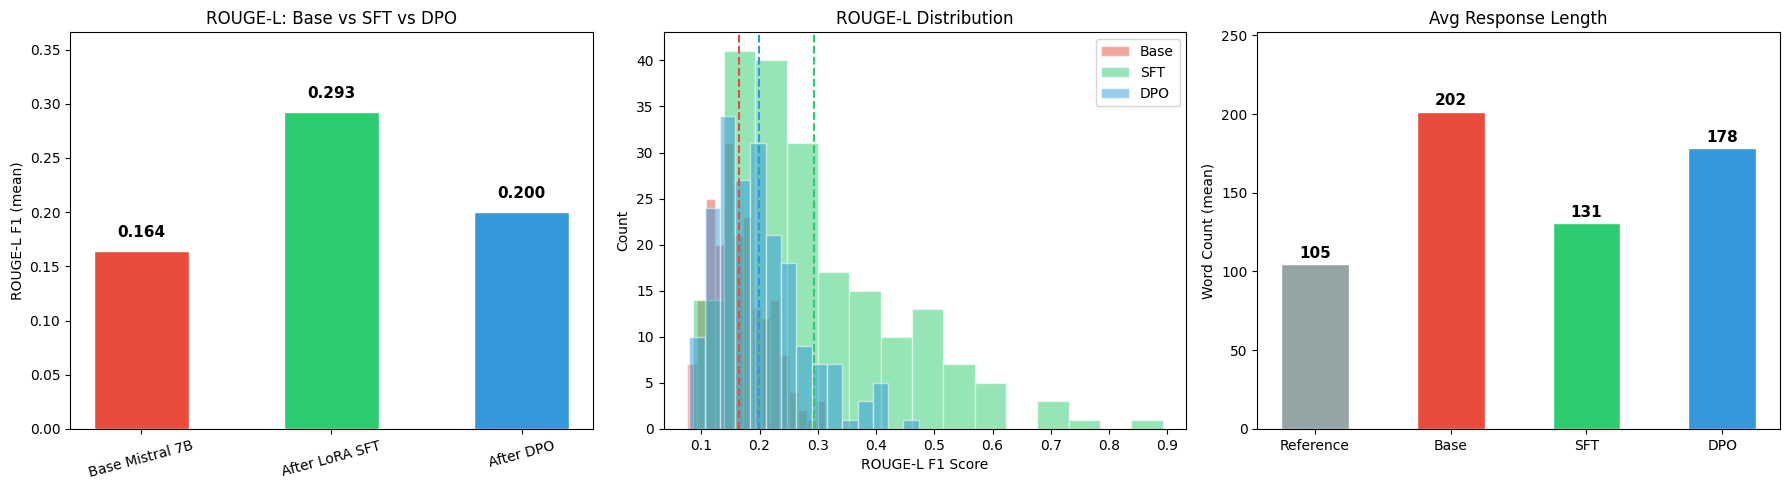

Saved chart to /kaggle/working/eval_metrics_charts.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: ROUGE-L comparison bar chart ──
ax = axes[0]
models = ["Base Mistral 7B", "After LoRA SFT", "After DPO"]
rouge_means = [statistics.mean(base_rouge_scores), statistics.mean(sft_rouge_scores), statistics.mean(dpo_rouge_scores)]
colors = ["#e74c3c", "#2ecc71", "#3498db"]
bars = ax.bar(models, rouge_means, color=colors, width=0.5, edgecolor="white")
for bar, val in zip(bars, rouge_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_ylabel("ROUGE-L F1 (mean)")
ax.set_title("ROUGE-L: Base vs SFT vs DPO")
ax.set_ylim(0, max(rouge_means) * 1.25)
ax.tick_params(axis='x', rotation=15)

# ── Plot 2: ROUGE-L histogram overlay ──
ax = axes[1]
ax.hist(base_rouge_scores, bins=15, alpha=0.5, label="Base", color="#e74c3c", edgecolor="white")
ax.hist(sft_rouge_scores, bins=15, alpha=0.5, label="SFT", color="#2ecc71", edgecolor="white")
ax.hist(dpo_rouge_scores, bins=15, alpha=0.5, label="DPO", color="#3498db", edgecolor="white")
ax.axvline(statistics.mean(base_rouge_scores), color="#e74c3c", linestyle="--", linewidth=1.5)
ax.axvline(statistics.mean(sft_rouge_scores), color="#2ecc71", linestyle="--", linewidth=1.5)
ax.axvline(statistics.mean(dpo_rouge_scores), color="#3498db", linestyle="--", linewidth=1.5)
ax.set_xlabel("ROUGE-L F1 Score")
ax.set_ylabel("Count")
ax.set_title("ROUGE-L Distribution")
ax.legend()

# ── Plot 3: Word count comparison ──
ax = axes[2]
x_pos = range(4)
wc_means = [statistics.mean(ref_wc), statistics.mean(base_wc), statistics.mean(sft_wc), statistics.mean(dpo_wc)]
wc_labels = ["Reference", "Base", "SFT", "DPO"]
wc_colors = ["#95a5a6", "#e74c3c", "#2ecc71", "#3498db"]
bars = ax.bar(x_pos, wc_means, color=wc_colors, width=0.5, edgecolor="white")
for bar, val in zip(bars, wc_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val:.0f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_xticks(x_pos)
ax.set_xticklabels(wc_labels)
ax.set_ylabel("Word Count (mean)")
ax.set_title("Avg Response Length")
ax.set_ylim(0, max(wc_means) * 1.25)

plt.tight_layout()
plt.savefig("/kaggle/working/eval_metrics_charts.png", bbox_inches="tight")
plt.show()
print("Saved chart to /kaggle/working/eval_metrics_charts.png")

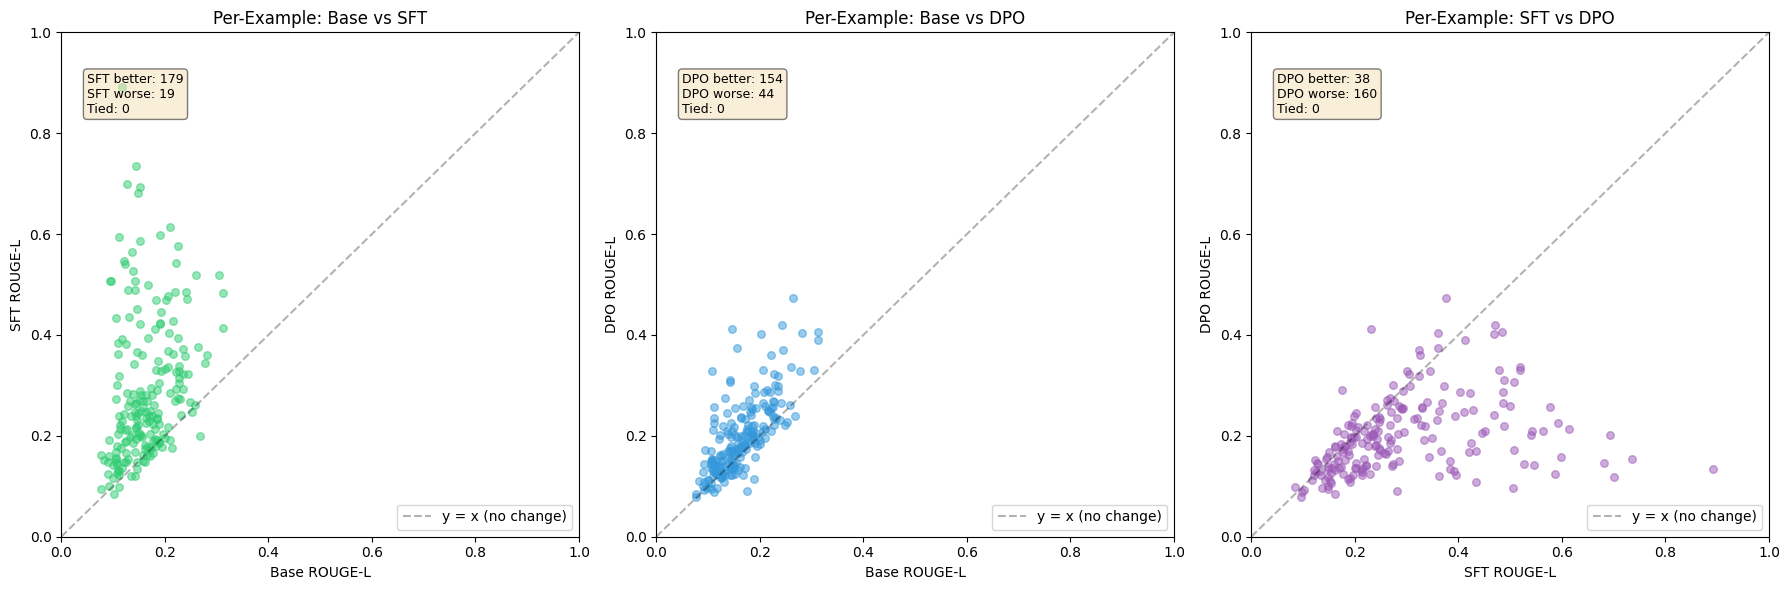

In [23]:
# Per-example ROUGE-L scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pairs = [
    ("Base", base_rouge_scores, "SFT", sft_rouge_scores, "#2ecc71"),
    ("Base", base_rouge_scores, "DPO", dpo_rouge_scores, "#3498db"),
    ("SFT", sft_rouge_scores, "DPO", dpo_rouge_scores, "#9b59b6"),
]

for ax, (lbl_x, scores_x, lbl_y, scores_y, color) in zip(axes, pairs):
    ax.scatter(scores_x, scores_y, alpha=0.5, s=30, color=color)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="y = x (no change)")
    ax.set_xlabel(f"{lbl_x} ROUGE-L")
    ax.set_ylabel(f"{lbl_y} ROUGE-L")
    ax.set_title(f"Per-Example: {lbl_x} vs {lbl_y}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right")

    y_better = sum(1 for a, b in zip(scores_x, scores_y) if b > a)
    y_worse = sum(1 for a, b in zip(scores_x, scores_y) if b < a)
    tied = len(scores_x) - y_better - y_worse
    ax.text(0.05, 0.92, f"{lbl_y} better: {y_better}\n{lbl_y} worse: {y_worse}\nTied: {tied}",
            transform=ax.transAxes, fontsize=9, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.savefig("/kaggle/working/rouge_scatter.png", bbox_inches="tight")
plt.show()

## 15. Side-by-Side Response Examples

Show 5 examples where DPO improved most over Base (by ROUGE-L gain), so we
can qualitatively inspect the progression from Base to SFT to DPO.

In [24]:
# Rank examples by ROUGE-L improvement (DPO - Base)
rouge_deltas = [(dpo_rouge_scores[i] - base_rouge_scores[i], i)
                for i in range(len(prompts))]
rouge_deltas.sort(reverse=True)

# Show top 5 improvements
NUM_EXAMPLES = 5
print(f"Top {NUM_EXAMPLES} examples where DPO improved most over Base:\n")

for rank, (delta, idx) in enumerate(rouge_deltas[:NUM_EXAMPLES], 1):
    print(f"{'=' * 70}")
    print(f"Example {rank} (index {idx}) | ROUGE-L: Base={base_rouge_scores[idx]:.3f}, SFT={sft_rouge_scores[idx]:.3f}, DPO={dpo_rouge_scores[idx]:.3f}")
    print(f"{'=' * 70}")
    print(f"\nPROMPT: {prompts[idx]}")
    print(f"\nREFERENCE (chosen):\n{chosen_refs[idx][:300]}")
    print(f"\nBASE RESPONSE:\n{base_responses[idx][:300]}")
    print(f"\nSFT RESPONSE:\n{sft_responses[idx][:300]}")
    print(f"\nDPO RESPONSE:\n{dpo_responses[idx][:300]}")
    print()

Top 5 examples where DPO improved most over Base:

Example 1 (index 22) | ROUGE-L: Base=0.146, SFT=0.231, DPO=0.411

PROMPT: What is the company match percentage for the retirement plan?

REFERENCE (chosen):
The provided context does not include information about the company match percentage for the retirement plan. Please check your company's retirement plan documentation or contact HR for that specific information.

BASE RESPONSE:
I'd be happy to help, but I'll need to clarify a few things first. The term "company match percentage" refers to the percentage of an employee's contributions to a retirement plan that the employer will match. However, this percentage can vary greatly from one company to another, and some companies 

SFT RESPONSE:
I'd need to refer to the specific HR policy documents or employee handbook that details the company's retirement plan to provide the exact company match percentage. Please let me know if you have access to that information, and I'll be happy to he

## 16. Save Metrics to CSV

In [25]:
import csv

METRICS_CSV = "/kaggle/working/metrics.csv"

metrics_rows = []
for label, rouge_scores, wc_list in [
    ("Base Mistral 7B", base_rouge_scores, base_wc),
    ("After LoRA SFT", sft_rouge_scores, sft_wc),
    ("After DPO", dpo_rouge_scores, dpo_wc),
]:
    metrics_rows.append({
        "model": label,
        "rouge_l_mean": round(statistics.mean(rouge_scores), 4),
        "rouge_l_median": round(statistics.median(rouge_scores), 4),
        "rouge_l_std": round(statistics.stdev(rouge_scores), 4),
        "word_count_mean": round(statistics.mean(wc_list), 1),
        "word_count_median": round(statistics.median(wc_list), 1),
        "word_count_std": round(statistics.stdev(wc_list), 1),
        "word_count_min": min(wc_list),
        "word_count_max": max(wc_list),
    })

fieldnames = list(metrics_rows[0].keys())
with open(METRICS_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(metrics_rows)

print(f"Metrics saved to {METRICS_CSV}")
for row in metrics_rows:
    print(f"  {row['model']}: ROUGE-L={row['rouge_l_mean']}, Words={row['word_count_mean']}")

Metrics saved to /kaggle/working/metrics.csv
  Base Mistral 7B: ROUGE-L=0.1642, Words=201.5
  After LoRA SFT: ROUGE-L=0.2928, Words=130.7
  After DPO: ROUGE-L=0.1998, Words=178.1


## 17. Final Evaluation Summary

In [26]:
base_rouge_mean = statistics.mean(base_rouge_scores)
sft_rouge_mean = statistics.mean(sft_rouge_scores)
dpo_rouge_mean = statistics.mean(dpo_rouge_scores)

# Count per-example wins
sft_better = sum(1 for b, s in zip(base_rouge_scores, sft_rouge_scores) if s > b)
sft_worse = sum(1 for b, s in zip(base_rouge_scores, sft_rouge_scores) if s < b)
dpo_better_base = sum(1 for b, d in zip(base_rouge_scores, dpo_rouge_scores) if d > b)
dpo_better_sft = sum(1 for s, d in zip(sft_rouge_scores, dpo_rouge_scores) if d > s)

print("=" * 78)
print("  EVALUATION SUMMARY: Base Mistral 7B vs LoRA SFT vs DPO")
print("=" * 78)
print(f"\n  Test set size:     {len(prompts)} examples")
print(f"  Base model:        {BASE_MODEL}")
print(f"  SFT adapter:       {SFT_ADAPTER_DIR}")
print(f"  DPO adapter:       {DPO_ADAPTER_DIR}")
print(f"\n  {'Metric':<30} {'Base':>10} {'SFT':>10} {'DPO':>10}")
print(f"  {'-' * 60}")
print(f"  {'ROUGE-L (mean)':<30} {base_rouge_mean:>10.4f} {sft_rouge_mean:>10.4f} {dpo_rouge_mean:>10.4f}")
print(f"  {'ROUGE-L (median)':<30} {statistics.median(base_rouge_scores):>10.4f} {statistics.median(sft_rouge_scores):>10.4f} {statistics.median(dpo_rouge_scores):>10.4f}")
print(f"  {'Word count (mean)':<30} {statistics.mean(base_wc):>10.1f} {statistics.mean(sft_wc):>10.1f} {statistics.mean(dpo_wc):>10.1f}")
print(f"  {'Word count (median)':<30} {statistics.median(base_wc):>10.1f} {statistics.median(sft_wc):>10.1f} {statistics.median(dpo_wc):>10.1f}")
print(f"\n  Pairwise ROUGE-L wins:")
print(f"    SFT > Base:  {sft_better:>3} / {len(prompts)}")
print(f"    DPO > Base:  {dpo_better_base:>3} / {len(prompts)}")
print(f"    DPO > SFT:   {dpo_better_sft:>3} / {len(prompts)}")
print(f"\n  Improvement over Base (ROUGE-L mean):")
print(f"    SFT: {sft_rouge_mean / base_rouge_mean:.2f}x ({sft_rouge_mean - base_rouge_mean:+.4f})")
print(f"    DPO: {dpo_rouge_mean / base_rouge_mean:.2f}x ({dpo_rouge_mean - base_rouge_mean:+.4f})")
print("=" * 78)

print("\n  Output files (download from Save Version -> Output):")
print("    - eval_results.json       (all responses)")
print("    - metrics.csv             (ROUGE-L + word count)")
print("    - eval_metrics_charts.png (bar charts)")
print("    - rouge_scatter.png       (scatter plots)")

  EVALUATION SUMMARY: Base Mistral 7B vs LoRA SFT vs DPO

  Test set size:     198 examples
  Base model:        mistralai/Mistral-7B-Instruct-v0.2
  SFT adapter:       /kaggle/input/datasets/aadityae/sft-adapter
  DPO adapter:       /kaggle/input/datasets/aadityae/dpo-adapter

  Metric                               Base        SFT        DPO
  ------------------------------------------------------------
  ROUGE-L (mean)                     0.1642     0.2928     0.1998
  ROUGE-L (median)                   0.1571     0.2490     0.1870
  Word count (mean)                   201.5      130.7      178.1
  Word count (median)                 215.0      133.0      198.0

  Pairwise ROUGE-L wins:
    SFT > Base:  179 / 198
    DPO > Base:  154 / 198
    DPO > SFT:    38 / 198

  Improvement over Base (ROUGE-L mean):
    SFT: 1.78x (+0.1285)
    DPO: 1.22x (+0.0356)

  Output files (download from Save Version -> Output):
    - eval_results.json       (all responses)
    - metrics.csv           

## 18. Zip All Outputs for Download

In [27]:
!cd /kaggle/working && zip -j eval_complete.zip eval_results.json metrics.csv eval_metrics_charts.png rouge_scatter.png
print("\nAll outputs zipped to eval_complete.zip")
print("Go to Save Version -> Quick Save -> Output tab to download.")

  adding: eval_results.json (deflated 74%)
  adding: metrics.csv (deflated 39%)
  adding: eval_metrics_charts.png (deflated 13%)
  adding: rouge_scatter.png (deflated 8%)

All outputs zipped to eval_complete.zip
Go to Save Version -> Quick Save -> Output tab to download.
